FileNotFoundError: [Errno 2] No such file or directory: 'Documents/chalmers/thesis/healpix.pdf'

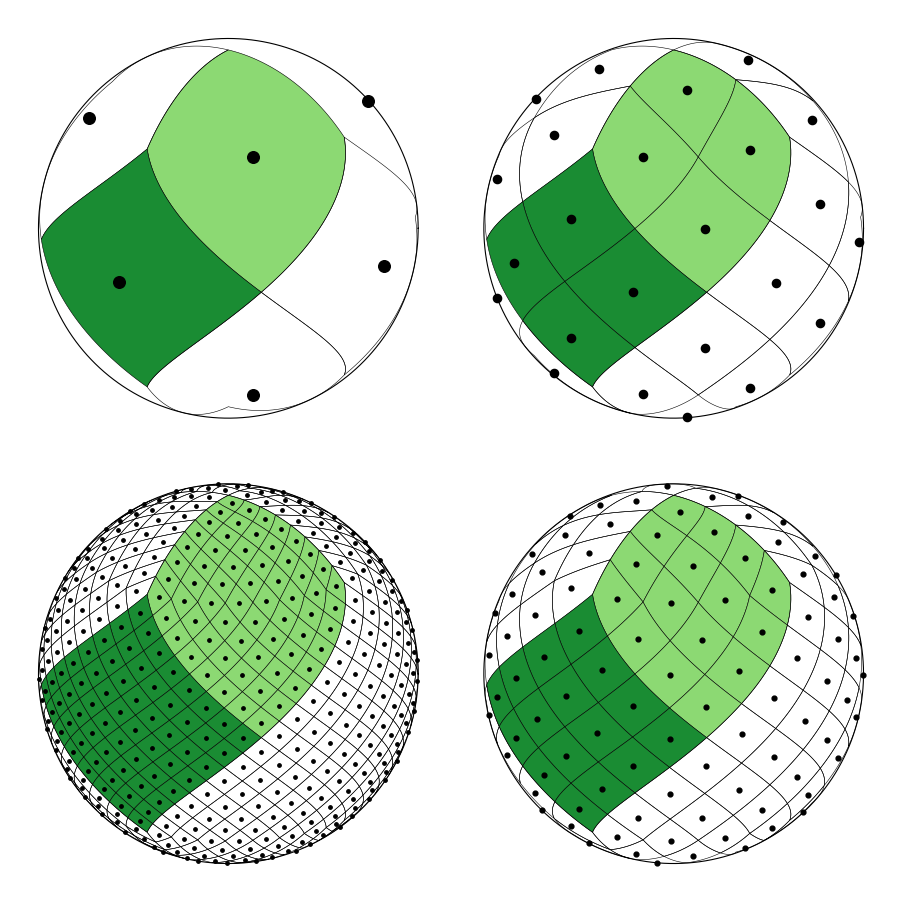

In [24]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Viewing direction (camera) - looking at the sphere from this lon/lat
VIEW_LON = 35.0   # degrees
VIEW_LAT = 20.0   # degrees

def sph_to_cart(lon_deg, lat_deg):
    lon = np.radians(lon_deg)
    lat = np.radians(lat_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.array([x, y, z])

# Camera basis
view = sph_to_cart(VIEW_LON, VIEW_LAT)          # outward viewing axis (toward camera)
up_world = np.array([0, 0, 1.0])
right = np.cross(up_world, view); right /= np.linalg.norm(right)
up = np.cross(view, right); up /= np.linalg.norm(up)

def project(vecs):
    """Orthographic projection onto the camera plane. vecs shape (...,3)."""
    vecs = np.atleast_2d(vecs)
    u = vecs @ right
    v = vecs @ up
    depth = vecs @ view  # >0 means front-facing (toward camera)
    return u, v, depth

def vec_from_thetaphi(theta, phi):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.stack([x, y, z], axis=-1)

def pixel_boundary_vertices(nside, ipix, step=20):
    """Get 3D vertices tracing the boundary of a HEALPix pixel."""
    bounds = hp.boundaries(nside, ipix, step=step, nest=False)  # shape (3, 4*step)
    return bounds.T  # (N,3)

def draw_panel(ax, nside, title):
    npix = hp.nside2npix(nside)

    # Determine which pixels to shade (one light-grey and one dark-grey quadrant
    # in the equatorial / mid region, like the reference figure)
    # We'll shade base-pixel regions. For nside=1 base pixels = pixel index.
    # Identify two adjacent equatorial base pixels to highlight.
    # Equatorial base pixels in RING for nside=1 are indices 4..7.
    # Map every pixel to its base pixel via nest indexing.
    ipix_all = np.arange(npix)
    ipix_nest = hp.ring2nest(nside, ipix_all)
    base_pixel = ipix_nest // (nside * nside)  # 0..11

    # Choose base pixels to color: one light (north), one dark (equatorial below it)
    light_base = 0   # north cap, upper-center
    dark_base = 4    # equatorial, directly below the light one

    # Draw all pixel boundaries
    for ipix in range(npix):
        verts = pixel_boundary_vertices(nside, ipix, step=max(8, 40 // nside))
        u, v, depth = project(verts)
        # Skip pixels whose center is clearly back-facing
        # (use a generous threshold so limb pixels still render partially)
        if np.max(depth) < 0.0:
            continue
        # Determine facecolor
        bp = base_pixel[ipix]
        if bp == light_base:
            fc = (0.55, 0.85, 0.45)   # light vivid green
        elif bp == dark_base:
            fc = (0.10, 0.55, 0.20)   # deep green
        else:
            fc = 'none'

        # Fade out the portion behind the limb by projecting onto sphere edge:
        # keep all verts but only fill/draw when majority is front-facing.
        if np.mean(depth > 0) < 0.6:
            continue

        ax.fill(u, v, facecolor=fc if fc != 'none' else 'none',
                edgecolor='black', linewidth=0.4, zorder=1)

    # Pixel centers (dots)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    centers = vec_from_thetaphi(theta, phi)
    cu, cv, cdepth = project(centers)
    front = cdepth > 0.02
    # marker size scales down with resolution
    msize = {1: 70, 2: 35, 4: 12, 8: 6}[nside]
    ax.scatter(cu[front], cv[front], s=msize, c='black', zorder=5)

    # Sphere outline
    circ = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(circ), np.sin(circ), color='black', linewidth=0.8, zorder=2)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    ax.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
configs = [
    (axes[0, 0], 1, "Nside=1, Npix=12"),
    (axes[0, 1], 2, "Nside=2, Npix=48"),
    (axes[1, 0], 8, "Nside=8, Npix=768"),
    (axes[1, 1], 4, "Nside=4, Npix=192"),
]
# Clockwise from upper-left: 1 (UL) -> 2 (UR) -> 4 (LR) -> 8 (LL)
for ax, nside, title in configs:
    draw_panel(ax, nside, title)

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)
plt.savefig('Documents/chalmers/thesis/healpix.pdf', dpi=150, bbox_inches='tight')
print("done")


In [5]:
!pip install globe

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
  Created wheel for globe: filename=globe-1.0.52-py3-none-any.whl size=23680 sha256=6c3bbb961a2670353c8d76301e74f9238d35e6ed4ef52313663c78fbb0b3de24
  Stored in directory: /home/x_tagty/.cache/pip/wheels/99/06/ad/716117f137638e9529bb35914dc09eee9947a8e63048122368
Successfully built globe


In [2]:
"""
Thesis cover — plasma palette, green outlines on the 12 base HEALPix pixels,
with a subtle land mask so the sphere reads as Earth (weather forecasting).

- Field: zonally symmetric (function of latitude only), SO(2)-invariant.
- Fine HEALPix grid (Nside=32) drawn subtly so it doesn't compete.
- HEALPix pixels whose centers lie over land are slightly darkened, so the
  continents are recognizable without breaking the SO(2) gradient story.
- The 12 base pixels (Nside=1) are outlined boldly in vivid green.
- A curved arrow traces a high-latitude ring to indicate rotation
  about the polar axis.
"""

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from global_land_mask import globe

# ---------- Camera ----------
VIEW_LON, VIEW_LAT = 25.0, 22.0
NSIDE = 64

def sph_to_cart(lo_d, la_d):
    lo, la = np.radians(lo_d), np.radians(la_d)
    return np.array([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)])

view = sph_to_cart(VIEW_LON, VIEW_LAT)
up_world = np.array([0, 0, 1.0])
right = np.cross(up_world, view); right /= np.linalg.norm(right)
up_cam = np.cross(view, right); up_cam /= np.linalg.norm(up_cam)

def project(vecs):
    vecs = np.atleast_2d(vecs)
    return vecs @ right, vecs @ up_cam, vecs @ view

# ---------- Zonally symmetric field ----------
def zonal_field(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    lat = np.pi / 2 - theta
    return np.cos(2 * lat) + 0.18 * np.cos(4 * lat)

# ---------- Fine HEALPix pixels with subtle grid + land darkening ----------
def draw_pixels(ax, nside, field, cmap, vmax,
                grid_color=(0, 0, 0, 0.20), grid_lw=0.30,
                land_darken=0.30):
    """`land_darken` in [0,1]: 0 = no effect, 1 = full black for land pixels."""
    norm = Normalize(-vmax, vmax)
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    lat_deg = np.degrees(np.pi / 2 - theta)
    lon_deg = ((np.degrees(phi) + 180) % 360) - 180  # to [-180, 180]
    is_land = globe.is_land(lat_deg, lon_deg)

    for ipix in range(npix):
        verts = hp.boundaries(nside, ipix, step=max(10, 48 // nside)).T
        u, v, d = project(verts)
        if np.mean(d > 0) < 0.55:
            continue
        rgba = list(cmap(norm(field[ipix])))
        if is_land[ipix]:
            for k in range(3):
                rgba[k] *= (1.0 - land_darken)
        ax.fill(u, v, facecolor=tuple(rgba),
                edgecolor=grid_color, linewidth=grid_lw, zorder=2)

# ---------- 12 base pixels in bold green ----------
def draw_base_pixels(ax, color='#1fff55', linewidth=2.8, halo=True):
    for ipix in range(12):
        verts = hp.boundaries(1, ipix, step=80).T
        verts = np.concatenate([verts, verts[:1]], axis=0)  # close loop
        u, v, d = project(verts)
        if np.max(d) < 0:
            continue
        front = d > 0
        u_p = np.where(front, u, np.nan)
        v_p = np.where(front, v, np.nan)
        if halo:
            # Soft dark halo so green pops against bright field regions
            ax.plot(u_p, v_p, color=(0, 0, 0, 0.55),
                    linewidth=linewidth + 1.6, zorder=6,
                    solid_capstyle='round', solid_joinstyle='round')
        ax.plot(u_p, v_p, color=color, linewidth=linewidth, zorder=7,
                solid_capstyle='round', solid_joinstyle='round')

# ---------- Rotation arrow (follows a circle of constant latitude) ----------
def draw_rotation_arrow(ax, lat_deg=62, phi_start_deg=-50, phi_end_deg=165,
                        color='black', linewidth=2.6, halo=True):
    """Curved arrow tracing a latitude ring — visualizes rotation about the polar axis."""
    th = np.pi / 2 - np.radians(lat_deg)
    z = np.cos(th); r = np.sin(th)
    phis = np.linspace(np.radians(phi_start_deg),
                       np.radians(phi_end_deg), 240)
    pts = np.stack([r * np.cos(phis), r * np.sin(phis),
                    np.full_like(phis, z)], axis=-1)
    u, v, d = project(pts)
    front_idx = np.where(d > 0)[0]
    if len(front_idx) < 4:
        return
    splits = np.where(np.diff(front_idx) > 1)[0]
    if len(splits):
        front_idx = front_idx[: splits[0] + 1]
    u_v, v_v = u[front_idx], v[front_idx]

    if halo:
        ax.plot(u_v[:-2], v_v[:-2], color=(1, 1, 1, 0.6),
                linewidth=linewidth + 0.9, zorder=8,
                solid_capstyle='round')
    ax.plot(u_v[:-2], v_v[:-2], color=color, linewidth=linewidth,
            zorder=9, solid_capstyle='round')

    from matplotlib.patches import FancyArrowPatch
    if halo:
        halo_arrow = FancyArrowPatch((u_v[-3], v_v[-3]), (u_v[-1], v_v[-1]),
                                     arrowstyle='-|>', mutation_scale=22,
                                     color=(1, 1, 1, 0.6),
                                     linewidth=linewidth + 0.9, zorder=8)
        ax.add_patch(halo_arrow)
    arrow = FancyArrowPatch((u_v[-3], v_v[-3]), (u_v[-1], v_v[-1]),
                            arrowstyle='-|>', mutation_scale=22,
                            color=color, linewidth=linewidth, zorder=9)
    ax.add_patch(arrow)

# ============================================================
#  Render
# ============================================================
field = zonal_field(NSIDE)
vmax = np.percentile(np.abs(field), 99)
cmap = plt.cm.plasma

fig, ax = plt.subplots(figsize=(8.5, 8.5), facecolor='white')
ax.set_facecolor('white')

draw_pixels(ax, NSIDE, field, cmap, vmax,
            grid_color=(0, 0, 0, 0.05), grid_lw=0.15,
            land_darken=0.22)
draw_base_pixels(ax, color='#1fff55', linewidth=2.8, halo=True)

# Sphere outline
t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(t), np.sin(t), color='black', linewidth=1.4, zorder=5)

draw_rotation_arrow(ax, lat_deg=62, phi_start_deg=-50, phi_end_deg=165,
                    color='black', linewidth=2.6, halo=True)

ax.set_xlim(-1.30, 1.30)
ax.set_ylim(-1.30, 1.30)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig('./cover_base.pdf', dpi=220,
            bbox_inches='tight', facecolor='white')
plt.close()
print("done")


done


Loading: /proj/heal_pangu/eqp_climate/artifacts/results/1001673730280906678_git_6221631_config_15c00d1a2980f6dd/spatial_rmse_tas_e160.npy
  NSIDE=32, npix=12288, RMSE range [0.0278, 0.5238]


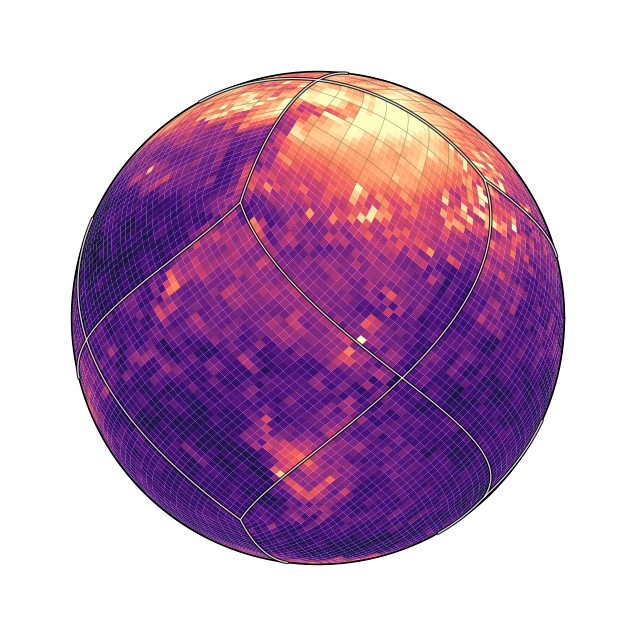

Saved: spatial_rmse_tas_e160.pdf


In [49]:
# ============================================================
#  CONFIG — change these to select which artifact to plot
# ============================================================
ARTIFACTS_ROOT = "/proj/heal_pangu/eqp_climate/artifacts/results"
MODEL_ID       = "1001673730280906678"   # model with both tas and pr artifacts
VARIABLE       = "tas"                   # "tas" or "pr"
EPOCH          = 160
DENORM         = False                   # True for physical units, False for normalized

VIEW_LON, VIEW_LAT = 25.0, 15.0         # camera direction
SHOW_BASE_PIXELS = True              # overlay the 12 Nside=1 base pixel outlines

# ============================================================
#  Load artifact
# ============================================================
import glob, numpy as np, healpy as hp, matplotlib.pyplot as plt
from matplotlib.colors import Normalize

prefix  = "spatial_rmse_denorm" if DENORM else "spatial_rmse"
pattern = f"{ARTIFACTS_ROOT}/{MODEL_ID}_git_*_config_*/{prefix}_{VARIABLE}_e{EPOCH}.npy"
matches = sorted(glob.glob(pattern))
if not matches:
    raise FileNotFoundError(f"No artifact found for:\n  {pattern}")
artifact_path = matches[-1]
print(f"Loading: {artifact_path}")

field = np.load(artifact_path)   # (P,)
npix  = len(field)
NSIDE = hp.npix2nside(npix)
print(f"  NSIDE={NSIDE}, npix={npix}, RMSE range [{field.min():.4f}, {field.max():.4f}]")

# ============================================================
#  Camera / projection
# ============================================================
def _sph_to_cart(lo_d, la_d):
    lo, la = np.radians(lo_d), np.radians(la_d)
    return np.array([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)])

_view    = _sph_to_cart(VIEW_LON, VIEW_LAT)
_up_w    = np.array([0, 0, 1.0])
_right   = np.cross(_up_w, _view);   _right  /= np.linalg.norm(_right)
_up_cam  = np.cross(_view, _right);  _up_cam /= np.linalg.norm(_up_cam)

def _project(vecs):
    vecs = np.atleast_2d(vecs)
    return vecs @ _right, vecs @ _up_cam, vecs @ _view

# ============================================================
#  Base-pixel overlay (12 Nside=1 blocks, same as cover cell)
# ============================================================
# color = 'white'            # clean, works on any dark cmap
# color = 'black'            # bold, works on light cmaps
# color = '#00cfff'          # cyan — pops on inferno/magma
# color = '#ff4444'          # red
# color = '#ffdd00'          # yellow — good on viridis/plasma
color = (1, 1, 1, 0.6)    # semi-transparent white, subtle
#color = (0, 0, 0, 0.4)    # semi-transparent black, very subtle
#color = '#1fff55'            # current: bright green
def _draw_base_pixels(ax, color=color, linewidth=0.8, halo=True):
    for ipix in range(12):
        verts = hp.boundaries(1, ipix, step=80, nest=True).T
        verts = np.concatenate([verts, verts[:1]], axis=0)
        u, v, d = _project(verts)
        if np.max(d) < 0:
            continue
        front = d > 0
        u_p = np.where(front, u, np.nan)
        v_p = np.where(front, v, np.nan)
        if halo:
            ax.plot(u_p, v_p, color=(0, 0, 0, 0.55),
                    linewidth=linewidth + 1.6, zorder=6,
                    solid_capstyle='round', solid_joinstyle='round')
        ax.plot(u_p, v_p, color=color, linewidth=linewidth, zorder=7,
                solid_capstyle='round', solid_joinstyle='round')

# ============================================================
#  Render
# ============================================================
vmin  = 0.0
vmax  = np.percentile(field, 98)
norm  = Normalize(vmin, vmax)

# ── SEQUENTIAL (low=good, high=bad) ─────────────────────────────────────────
#cmap = plt.cm.hot_r           # 1. classic heat: white→yellow→red (your current)
#cmap = plt.cm.YlOrRd        # 2. yellow→orange→red, softer than hot_r
#cmap = plt.cm.OrRd          # 3. orange→red, cleaner mid-range
#cmap = plt.cm.plasma        # 4. purple→orange→yellow, perceptually uniform
#cmap = plt.cm.inferno       # 5. black→purple→orange→yellow (dramatic, dark bg too)
cmap = plt.cm.magma         # 6. like inferno but cooler tones, less saturated
#cmap = plt.cm.RdPu          # 7. white→pink→purple, distinctive for error maps
#cmap = plt.cm.Reds          # 8. clean white→red, minimal, easy to read

#cmap = plt.cm.viridis        # 1. purple→blue→green→yellow — the classic, very publication-safe
#cmap = plt.cm.cividis        # 2. like viridis but colorblind-safe (blue→olive→yellow)
# cmap = plt.cm.turbo          # 3. full rainbow but perceptually smoother than jet, has vivid green mid-range
# cmap = plt.cm.gnuplot2       # 4. black→blue→green→yellow→white, dramatic
#cmap = plt.cm.gist_earth     # 5. blue→green→tan→white, natural/terrain feel

# ── DIVERGING (only useful if you remap vmin to a non-zero midpoint) ─────────
# cmap = plt.cm.RdYlGn_r      # 9. green(low)→yellow→red(high), intuitive for "bad"
# cmap = plt.cm.coolwarm_r    # 10. blue(low)→white→red(high), clean for presentations
fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
ax.set_facecolor('white')

step = max(4, 48 // NSIDE)
for ipix in range(npix):
    verts = hp.boundaries(NSIDE, ipix, step=step, nest=True).T
    u, v, d = _project(verts)
    if np.mean(d > 0) < 0.55:
        continue
    ax.fill(u, v, facecolor=cmap(norm(field[ipix])), edgecolor='none', zorder=2)

# Coarse grid lines
nside_grid = min(NSIDE, 8)
for ipix_c in range(hp.nside2npix(nside_grid)):
    verts = hp.boundaries(nside_grid, ipix_c, step=16, nest=True).T
    u, v, d = _project(verts)
    if np.mean(d > 0) < 0.55:
        continue
    ax.fill(u, v, facecolor='none', edgecolor=(0, 0, 0, 0.20), linewidth=0.4, zorder=3)

# Sphere outline
t = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(t), np.sin(t), color='black', linewidth=1.2, zorder=5)

if SHOW_BASE_PIXELS:
    _draw_base_pixels(ax)

# Colorbar
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
# unit_label = " (physical units)" if DENORM else " (normalized)"
# cbar.set_label(f"Spatial RMSE — {VARIABLE}{unit_label}", fontsize=12)

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect('equal')
ax.axis('off')
#ax.set_title(f"Spatial RMSE  |  model {MODEL_ID[:8]}…  |  var={VARIABLE}  |  epoch={EPOCH}", fontsize=11, pad=8)
# plt.tight_layout()
# plt.show()
# print("done")

out_path = f"spatial_rmse_{VARIABLE}_e{EPOCH}.pdf"
plt.savefig(out_path, dpi=300, bbox_inches='tight', format='pdf')
plt.show()
print(f"Saved: {out_path}")

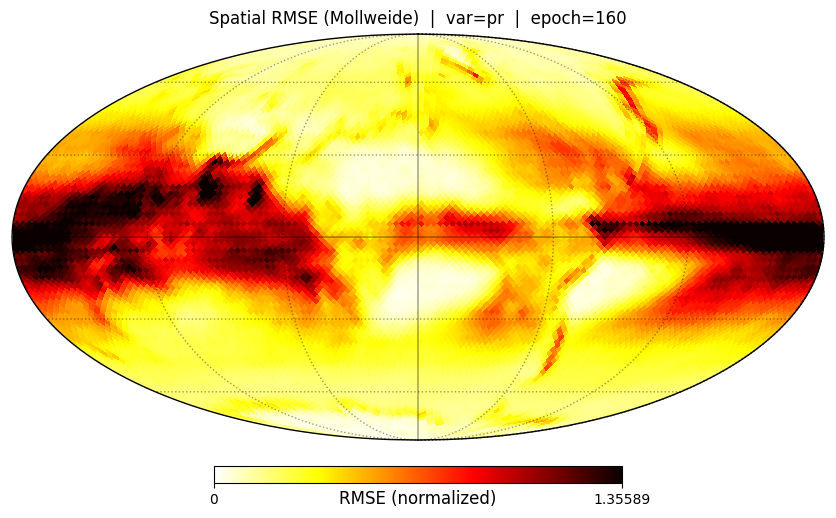

In [12]:
# Mollweide sanity-check — same field as the custom sphere above.
# Requires field, NSIDE, VARIABLE, EPOCH, DENORM from the cell above.

vmax_moll = np.percentile(field, 98)
hp.mollview(
    field,
    title=f"Spatial RMSE (Mollweide)  |  var={VARIABLE}  |  epoch={EPOCH}",
    cmap="hot_r",
    min=0,
    max=vmax_moll,
    unit=f"RMSE {'(physical)' if DENORM else '(normalized)'}",
    xsize=1600,
    nest=True,
)
hp.graticule(dpar=30, dmer=60, alpha=0.4)
plt.show()


Loading ssp245 · May 2060 ...
climate_model=BCC-CSM2-MR, ensemble=r1i1p1f1, seed=0
Using 16 workers [SLURM_CPUS_ON_NODE]
Loading cached INPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_nside32_BC_CH4_SO2_CO2_ssp245_2015-2100_nohistoric_anthro-fires
  Loaded INPUT from cache: shape=(1032, 4, 12288)
Loading cached OUTPUT data from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_BCC-CSM2-MR_r1i1p1f1_nside32_tas_pr_ssp245_2015-2100_nohistoric_250_km
  Loaded OUTPUT from cache: shape=(1032, 2, 12288)
Using 1032 start indices for split='test' (seq_len=1)
  split='test': stats must be provided explicitly.
  Call set_normalization_stats() before using this dataset.
Loaded input stats from /proj/heal_pangu/users/x_tagty/climateset/cache/inputs_nside32_BC_CH4_SO2_CO2_ssp126_ssp370_ssp585_2015-2100_nohistoric_anthro-fires/train_stats_seed1_valfrac0.1.npy
Loaded output stats from /proj/heal_pangu/users/x_tagty/climateset/cache/outputs_BCC-CSM2-MR_r1i1p1f1_nside32_tas_

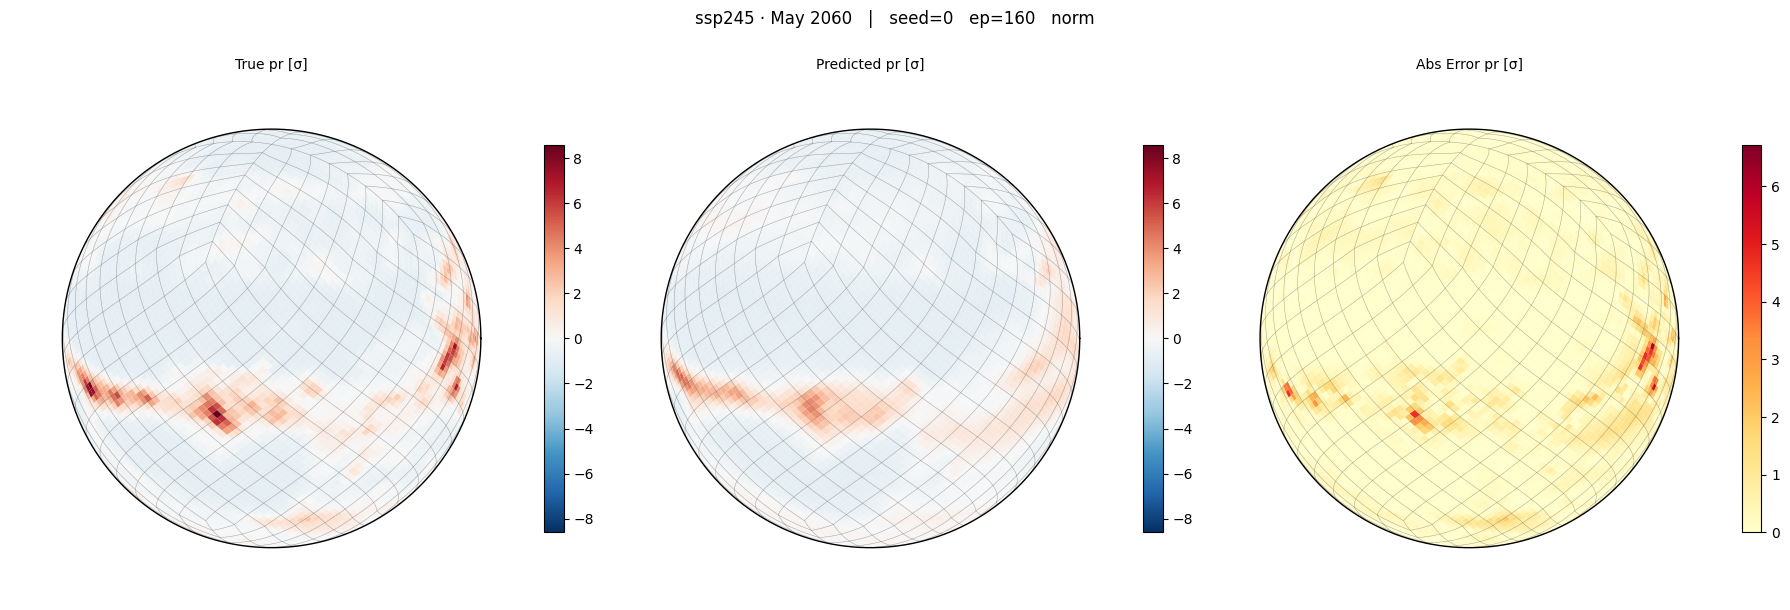

Single-sample RMSE (pr, norm): 0.52347 [σ]


In [13]:
# ============================================================
#  CONFIG
# ============================================================
# The spatial_rmse_*.npy artifacts (cells above) show RMSE *averaged over the
# entire test set* — one error value per HEALPix pixel.  This cell loads a
# single timestep and shows the actual field: True | Predicted | Error.

import sys
sys.path.insert(0, "/home/x_tagty/equivariant-posteriors")

HP_CONFIG         = "/home/x_tagty/equivariant-posteriors/experiments/climate/persisted_configs/final_climate_pear_runs/train_climate_pear_multiseed.py"
EPOCH             = 160          # checkpoint epoch to load
CLIMATE_MODEL_IDX = 1            # which CMIP6 climate model (0-indexed)
SEED              = 0            # ensemble / seed index
TARGET_YEAR       = 2060
TARGET_MONTH      = 5            # 1=Jan ... 12=Dec
VARIABLE          = "pr"        # "tas" or "pr"
DENORM            = False        # True → physical units (K / kg m⁻² s⁻¹), False → normalised (σ)
LOG_SCALE         = False        # True → SymLogNorm on field, LogNorm on error (useful for pr)

VIEW_LON, VIEW_LAT = 25.0, 22.0  # camera direction (same as cover cell)

# ============================================================
#  Load a single sample
# ============================================================
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from experiments.climate.notebooks.sample_predictions import get_predictions_for_timestamp
from experiments.climate.evaluation.evaluate_climate_hp import load_create_config as load_hp_config
from experiments.climate.evaluation.timestamp_utils import format_timestamp

hp_base    = load_hp_config(HP_CONFIG)
hp_curried = lambda ensemble_id, **kw: hp_base(
    ensemble_id=ensemble_id, climate_model_idx=CLIMATE_MODEL_IDX, **kw
)

print(f"Loading {format_timestamp('ssp245', TARGET_YEAR, TARGET_MONTH)} ...")
r = get_predictions_for_timestamp(
    hp_curried, EPOCH, year=TARGET_YEAR, month=TARGET_MONTH, variant_idx=SEED
)
print(f"  {r['model_name']}  {r['timestamp_label']}  shape={r['prediction'].shape}  nside={r['nside']}")

var_idx = r["var_names"].index(VARIABLE)
nside   = r["nside"]

if DENORM:
    true_field = r["target"][var_idx]
    pred_field = r["prediction"][var_idx]
    err_field  = r["error"][var_idx]
    unit = "K" if VARIABLE == "tas" else "kg m⁻² s⁻¹"
else:
    true_field = r["target_norm"][var_idx]
    pred_field = r["prediction_norm"][var_idx]
    err_field  = r["error_norm"][var_idx]
    unit = "σ"

# ============================================================
#  Camera / projection  (identical to the cover cell)
# ============================================================
def _sph_to_cart(lo_d, la_d):
    lo, la = np.radians(lo_d), np.radians(la_d)
    return np.array([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)])

_view   = _sph_to_cart(VIEW_LON, VIEW_LAT)
_up_w   = np.array([0, 0, 1.0])
_right  = np.cross(_up_w, _view);  _right  /= np.linalg.norm(_right)
_up_cam = np.cross(_view, _right); _up_cam /= np.linalg.norm(_up_cam)

def _project(vecs):
    vecs = np.atleast_2d(vecs)
    return vecs @ _right, vecs @ _up_cam, vecs @ _view

# ============================================================
#  Sphere drawing helper
# ============================================================
def draw_sphere(ax, field, norm_obj, cmap, title):
    npix  = len(field)
    nside = hp.npix2nside(npix)
    step  = max(4, 48 // nside)

    for ipix in range(npix):
        verts = hp.boundaries(nside, ipix, step=step, nest=True).T
        u, v, d = _project(verts)
        if np.mean(d > 0) < 0.55:
            continue
        ax.fill(u, v, facecolor=cmap(norm_obj(field[ipix])), edgecolor='none', zorder=2)

    # Coarse grid overlay
    nside_g = min(nside, 8)
    for ipix_c in range(hp.nside2npix(nside_g)):
        verts = hp.boundaries(nside_g, ipix_c, step=16, nest=True).T
        u, v, d = _project(verts)
        if np.mean(d > 0) < 0.55:
            continue
        ax.fill(u, v, facecolor='none', edgecolor=(0, 0, 0, 0.18), linewidth=0.35, zorder=3)

    # Sphere outline
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), color='black', linewidth=1.0, zorder=5)

    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10, pad=6)

# ============================================================
#  Norms
# ============================================================
def _make_norm(vmin, vmax, log=False):
    if not log:
        return mcolors.Normalize(vmin=vmin, vmax=vmax)
    if vmin >= 0:
        return mcolors.LogNorm(vmin=max(vmin, vmax * 1e-4, 1e-10), vmax=vmax)
    linthresh = max(abs(vmin), abs(vmax)) * 0.01
    return mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)

abs_max = max(abs(true_field).max(), abs(pred_field).max())
vmin_f, vmax_f = (-abs_max, abs_max) if not DENORM else (
    min(true_field.min(), pred_field.min()),
    max(true_field.max(), pred_field.max()),
)
norm_field = _make_norm(vmin_f, vmax_f, log=LOG_SCALE)
norm_err   = _make_norm(0, err_field.max(), log=LOG_SCALE)

log_tag = "  [log]" if LOG_SCALE else ""
ts_str  = r["timestamp_label"]

panels = [
    (true_field, f"True {VARIABLE} [{unit}]{log_tag}",      plt.cm.RdBu_r, norm_field),
    (pred_field, f"Predicted {VARIABLE} [{unit}]{log_tag}", plt.cm.RdBu_r, norm_field),
    (err_field,  f"Abs Error {VARIABLE} [{unit}]{log_tag}", plt.cm.YlOrRd, norm_err),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), facecolor='white')
fig.suptitle(f"{ts_str}   |   seed={SEED}   ep={EPOCH}   {'denorm' if DENORM else 'norm'}", fontsize=12)

for ax, (field_arr, title, cmap, norm_obj) in zip(axes, panels):
    draw_sphere(ax, field_arr, norm_obj, cmap, title)

# Colorbars
for ax, (_, _, cmap, norm_obj) in zip(axes, panels):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_obj)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, shrink=0.75)

plt.tight_layout()
plt.show()

rmse = float(np.sqrt(np.mean((pred_field - true_field) ** 2)))
print(f"Single-sample RMSE ({VARIABLE}, {'denorm' if DENORM else 'norm'}): {rmse:.5f} [{unit}]")
